# 06 - model evaluation

## 06.2 - 1d cnn on log-mel-spectrograms

**purpose**: evaluate the lightweight 1d cnn (trained in 05.2) on the **validation set** (speakers 20-22). the val set is used during model development for hyperparameter selection and early stopping. the held-out test set (speakers 23-24) is reserved for 07. cpu inference latency is measured in 07 (the production-readiness check), not here.

**input**: `data/processed/X_val_mel.npy`, `y_val.npy`, `data/models/cnn1d_best.pth`

**output**:
- `docs/02-results/figures/fig06-cnn1d_confusion_matrix.png`
- `data/predictions/eval_results_cnn.json` (consumed by 08)

In [1]:
import sys
sys.path.append("../../")

**import evaluation modules**. we load json, numpy, matplotlib, seaborn, sklearn metrics, and the cnn model helpers.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from src.config.config import settings
from src.models.cnn1d_model import load_cnn, predict_cnn, count_parameters

## Load saved model

In [3]:
device = settings.TORCH_DEVICE
model = load_cnn(settings.MODELS_DIR / "cnn1d_best.pth", device=device)
params = count_parameters(model)

**confirm model parameters**. the model has ~133k parameters, confirming the lightweight design.

In [4]:
print(f"Model loaded from {settings.MODELS_DIR / 'cnn1d_best.pth'}")
print(f"Total parameters: {params:,}")

Model loaded from E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\models\cnn1d_best.pth
Total parameters: 132,806


## Load validation data (log-mel-spectrogram, speakers 20-22)

In [5]:
X_val = np.load(settings.PROCESSED_DIR / "X_val_mel.npy")
y_val = np.load(settings.PROCESSED_DIR / "y_val.npy")

**verify validation data**. check shape and speakers match expectations.

In [6]:
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}  (speakers {settings.VAL_ACTORS})")
assert X_val.shape[1:] == (settings.N_MELS, settings.N_MELS_FRAMES), (
    f"expected mel shape ({settings.N_MELS}, {settings.N_MELS_FRAMES}), got {X_val.shape[1:]}"
)

X_val: (264, 128, 251)
y_val: (264,)  (speakers [20, 21, 22])


## Evaluate on val set

In [7]:
val_preds, _ = predict_cnn(model, X_val, batch_size=settings.CNN_1D_BATCH_SIZE, device=device)
val_acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Validation Accuracy: 75.38%


## Classification report

In [8]:
print("Classification Report:")
print(classification_report(y_val, val_preds, target_names=settings.EMOTION_NAMES))

Classification Report:
              precision    recall  f1-score   support

     neutral       0.79      0.79      0.79        24
        calm       0.82      0.83      0.82        48
       happy       0.82      0.67      0.74        48
         sad       0.77      0.75      0.76        48
       angry       0.70      0.90      0.79        48
     fearful       0.66      0.60      0.63        48

    accuracy                           0.75       264
   macro avg       0.76      0.76      0.75       264
weighted avg       0.76      0.75      0.75       264



## Confusion matrix

Saved confusion matrix to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\docs\02-results\figures\fig06-cnn1d_confusion_matrix.png


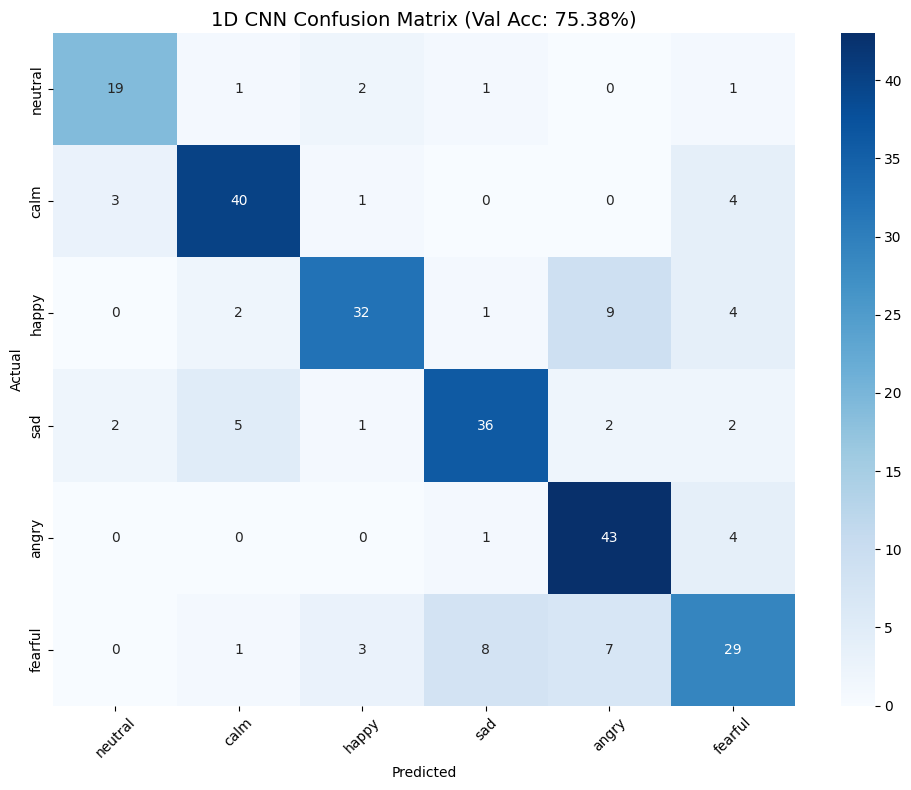

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=settings.EMOTION_NAMES,
            yticklabels=settings.EMOTION_NAMES, ax=ax)
ax.set_title(f'1D CNN Confusion Matrix (Val Acc: {val_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(settings.FIGURES_DIR / "fig06-cnn1d_confusion_matrix.png", dpi=150, bbox_inches="tight")
print(f"Saved confusion matrix to {settings.FIGURES_DIR / 'fig06-cnn1d_confusion_matrix.png'}")
plt.show()

## Per-emotion accuracy breakdown

In [10]:
per_class = {}
print(f"{'emotion':<12} {'support':>8} {'correct':>8} {'acc':>8}")
for i, name in enumerate(settings.EMOTION_NAMES):
    mask = y_val == i
    total = int(mask.sum())
    correct = int((val_preds[mask] == i).sum())
    acc = correct / total * 100 if total else 0.0
    per_class[name] = {"support": total, "correct": correct, "acc": round(acc / 100, 4)}
    print(f"{name:<12} {total:>8d} {correct:>8d} {acc:>7.1f}%")

emotion       support  correct      acc
neutral            24       19    79.2%
calm               48       40    83.3%
happy              48       32    66.7%
sad                48       36    75.0%
angry              48       43    89.6%
fearful            48       29    60.4%


## Save results to JSON (consumed by 08)

In [14]:
results = {
    "model":      "cnn1d",
    "split":      "val",
    "n_samples":  int(len(y_val)),
    "accuracy":   float(val_acc),
    "per_class":  per_class,
    "confusion_matrix": cm.tolist(),
    "emotion_names":    list(settings.EMOTION_NAMES),
    "parameters": int(params),
    "speakers":   list(settings.VAL_ACTORS),
}
print(json.dumps(results, indent=4))

{
    "model": "cnn1d",
    "split": "val",
    "n_samples": 264,
    "accuracy": 0.7537878787878788,
    "per_class": {
        "neutral": {
            "support": 24,
            "correct": 19,
            "acc": 0.7917
        },
        "calm": {
            "support": 48,
            "correct": 40,
            "acc": 0.8333
        },
        "happy": {
            "support": 48,
            "correct": 32,
            "acc": 0.6667
        },
        "sad": {
            "support": 48,
            "correct": 36,
            "acc": 0.75
        },
        "angry": {
            "support": 48,
            "correct": 43,
            "acc": 0.8958
        },
        "fearful": {
            "support": 48,
            "correct": 29,
            "acc": 0.6042
        }
    },
    "confusion_matrix": [
        [
            19,
            1,
            2,
            1,
            0,
            1
        ],
        [
            3,
            40,
            1,
            0,
      

**ensure predictions directory**. create output dir if needed.

In [15]:
results_path = settings.PREDICTIONS_DIR / "eval_results_cnn.json"
results_path.parent.mkdir(parents=True, exist_ok=True)

**save results to json**. persist evaluation results.

In [16]:
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved evaluation results to {results_path}")

Saved evaluation results to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\predictions\eval_results_cnn.json
